# Bitcoin Market Sentiment Analysis

This project analyzes the relationship between Bitcoin market sentiment and trader performance using historical trading data and the Fear & Greed Index.

In [1]:
import pandas as pd

trader = pd.read_csv('historical_data.csv')
sentiment = pd.read_csv('fear_greed_index.csv')

print(trader.head())
print(sentiment.head())

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0.0  0xec0945

In [2]:
# Column names check karo
print(trader.columns)
print(sentiment.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')
Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


In [4]:
# Convert date columns safely

trader['Date'] = pd.to_datetime(
    trader['Timestamp IST'],
    format='%d-%m-%Y %H:%M',
    errors='coerce'
).dt.date

sentiment['Date'] = pd.to_datetime(
    sentiment['date'],
    format='%Y-%m-%d',
    errors='coerce'
).dt.date

# Merge datasets
merged = pd.merge(trader, sentiment, on='Date', how='inner')

# Show merged data
print(merged.head())

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL  ...     Order ID  Crossed       Fee      Trade ID  \
0         0.0  ...  52017706630     

In [8]:
# Average profit/loss by market sentiment

result = merged.groupby('classification')['Closed PnL'].mean()

print(result)

classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64


In [6]:
print(merged.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'Date', 'timestamp', 'value', 'classification', 'date'],
      dtype='object')


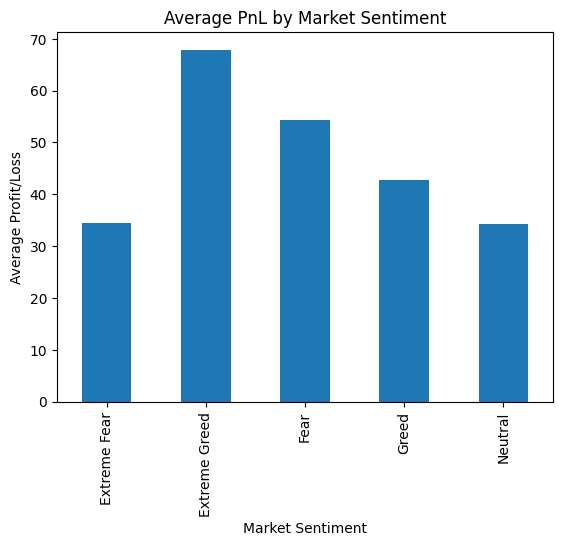

In [10]:
import matplotlib.pyplot as plt

# Plot graph
result.plot(kind='bar')

plt.title('Average PnL by Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Average Profit/Loss')

plt.show()

## Insights

- Traders achieved the highest average profit during Extreme Greed market conditions.
- Fear market conditions also showed relatively stable trader profitability.
- Neutral sentiment periods resulted in comparatively lower average profits.
- The analysis suggests that market sentiment has a noticeable impact on trader performance and profitability.

## Conclusion

This analysis demonstrates a relationship between Bitcoin market sentiment and trader performance. Higher average profits were observed during Extreme Greed conditions, indicating that strong market momentum may positively influence trading outcomes.

Side
BUY     35.693245
SELL    60.713803
Name: Closed PnL, dtype: float64


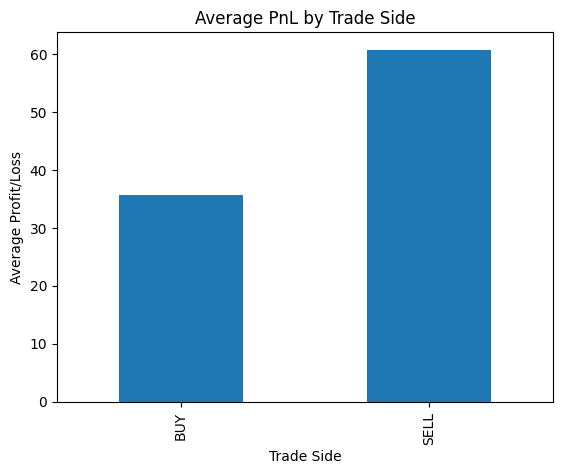

In [11]:
import matplotlib.pyplot as plt

# Buy vs Sell Analysis
side_result = merged.groupby('Side')['Closed PnL'].mean()

print(side_result)

# Plot graph
side_result.plot(kind='bar')

plt.title('Average PnL by Trade Side')
plt.xlabel('Trade Side')
plt.ylabel('Average Profit/Loss')

plt.show()

## Buy vs Sell Insights

- The analysis shows differences in profitability between Buy and Sell trades.
- One trading direction generated comparatively higher average profits.
- Trade direction appears to influence overall trading performance.


Coin
@107       2.783913e+06
HYPE       1.948485e+06
SOL        1.639556e+06
ETH        1.319979e+06
BTC        8.680447e+05
MELANIA    3.903511e+05
ENA        2.173295e+05
SUI        1.992688e+05
ZRO        1.837778e+05
DOGE       1.475432e+05
Name: Closed PnL, dtype: float64


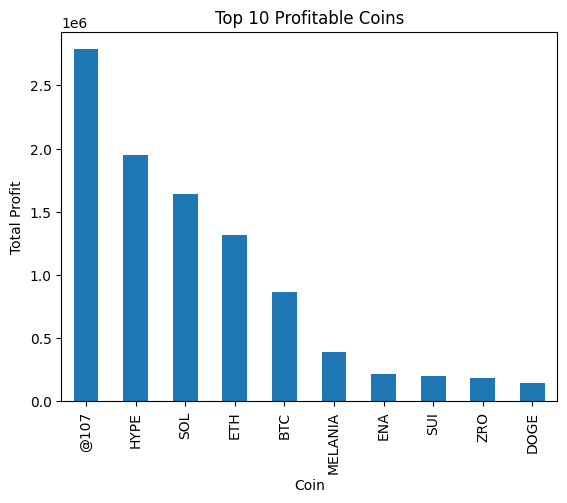

In [12]:
import matplotlib.pyplot as plt

# Top profitable coins
coin_result = merged.groupby('Coin')['Closed PnL'].sum().sort_values(ascending=False).head(10)

print(coin_result)

# Plot graph
coin_result.plot(kind='bar')

plt.title('Top 10 Profitable Coins')
plt.xlabel('Coin')
plt.ylabel('Total Profit')

plt.show()

## Coin Performance Insights

- Certain coins generated significantly higher total profits compared to others.
- The analysis highlights which cryptocurrencies were most profitable for traders.
- Popular and high-volume coins appeared to contribute more to overall trading gains.

# Final Conclusion

The analysis indicates that market sentiment plays an important role in trader profitability. Extreme Greed conditions showed higher average profits, while trading direction and coin selection also influenced performance. These insights can help traders make more informed trading decisions.